# 04 - Analyse NLP des Avis Clients

## Objectif: Analyser les avis textuels pour extraire le sentiment

### Architecture:
- **Données**: airlines_reviews.csv (8,100 avis)
- **NLP**: spaCy (moderne, rapide)
- **Approches**: TF-IDF + ML models
- **Visualisation**: WordCloud, Sentiment Distribution

In [53]:
# 1. Imports et Configuration
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import logging
import joblib
import re
from datetime import datetime
from collections import Counter

warnings.filterwarnings('ignore')

# NLP moderne avec spaCy
import spacy
from spacy.lang.en.stop_words import STOP_WORDS
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                           f1_score, classification_report, confusion_matrix,
                           roc_auc_score, roc_curve)
from wordcloud import WordCloud

# Charger le modele spaCy
try:
    nlp = spacy.load('en_core_web_sm')
    print("✅ spaCy model loaded")
except OSError:
    print("⚠️ Téléchargement du modèle spaCy...")
    spacy.cli.download('en_core_web_sm')
    nlp = spacy.load('en_core_web_sm')

# Configuration
PROJECT_ROOT = Path("/home/esprit/airlLines_Project")
CSV_DIR = PROJECT_ROOT / "dataSetAirlines"
RESULTS_DIR = PROJECT_ROOT / "results_nlp"
RESULTS_DIR.mkdir(exist_ok=True)

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 8)

# Configuration du logging
log_file = RESULTS_DIR / 'nlp_training.log'
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler(log_file),
        logging.StreamHandler()
    ]
)
logger = logging.getLogger(__name__)
logger.info("=== NLP SESSION START ===")
logger.info(f"Dataset: airlines_reviews.csv")
logger.info(f"NLP: spaCy {spacy.__version__}")
logger.info(f"Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

print("\n📦 Configuration NLP chargée")
print(f"   CSV: {CSV_DIR}")
print(f"   Results: {RESULTS_DIR}")
print(f"   Log file: {log_file}")
print(f"   spaCy version: {spacy.__version__}")

2026-05-25 01:24:25,103 - INFO - === NLP SESSION START ===
2026-05-25 01:24:25,109 - INFO - Dataset: airlines_reviews.csv
2026-05-25 01:24:25,111 - INFO - NLP: spaCy 3.8.14
2026-05-25 01:24:25,112 - INFO - Date: 2026-05-25 01:24:25


✅ spaCy model loaded

📦 Configuration NLP chargée
   CSV: /home/esprit/airlLines_Project/dataSetAirlines
   Results: /home/esprit/airlLines_Project/results_nlp
   Log file: /home/esprit/airlLines_Project/results_nlp/nlp_training.log
   spaCy version: 3.8.14


In [54]:
# 2. Chargement et Exploration des Données
print("\n" + "="*60)
print("2. CHARGEMENT ET EXPLORATION")
print("="*60)

# Chargement
df = pd.read_csv(CSV_DIR / "airlines_reviews.csv")

print(f"\n📊 Dataset: {df.shape[0]} lignes, {df.shape[1]} colonnes")
print(f"\n📋 Colonnes: {list(df.columns)}")
print(f"\n🔍 Valeurs manquantes:\n{df.isnull().sum()}")

# Distribution des notes
print(f"\n📈 Distribution Overall Rating:")
rating_dist = df['Overall Rating'].value_counts().sort_index()
for rating, count in rating_dist.items():
    print(f"   {rating}⭐: {count} avis ({count/len(df)*100:.1f}%)")

# Création de la cible binaire
df['sentiment_binary'] = (df['Overall Rating'] >= 7).astype(int)
df['sentiment_label'] = df['sentiment_binary'].map({0: 'Negative', 1: 'Positive'})

print(f"\n🎯 Distribution du sentiment:")
print(f"   Positif (≥7⭐): {(df['sentiment_binary']==1).sum()} avis ({df['sentiment_binary'].mean()*100:.1f}%)")
print(f"   Négatif (≤6⭐): {(df['sentiment_binary']==0).sum()} avis ({(1-df['sentiment_binary'].mean())*100:.1f}%)")


2. CHARGEMENT ET EXPLORATION

📊 Dataset: 8100 lignes, 17 colonnes

📋 Colonnes: ['Title', 'Name', 'Review Date', 'Airline', 'Verified', 'Reviews', 'Type of Traveller', 'Month Flown', 'Route', 'Class', 'Seat Comfort', 'Staff Service', 'Food & Beverages', 'Inflight Entertainment', 'Value For Money', 'Overall Rating', 'Recommended']

🔍 Valeurs manquantes:
Title                     0
Name                      0
Review Date               0
Airline                   0
Verified                  0
Reviews                   0
Type of Traveller         0
Month Flown               0
Route                     0
Class                     0
Seat Comfort              0
Staff Service             0
Food & Beverages          0
Inflight Entertainment    0
Value For Money           0
Overall Rating            0
Recommended               0
dtype: int64

📈 Distribution Overall Rating:
   1⭐: 1808 avis (22.3%)
   2⭐: 692 avis (8.5%)
   3⭐: 522 avis (6.4%)
   4⭐: 381 avis (4.7%)
   5⭐: 436 avis (5.4%)
   6⭐: 

In [55]:
# 3. Prétraitement NLP avec spaCy
print("\n" + "="*60)
print("3. PRÉTRAITEMENT NLP AVEC spaCy")
print("="*60)

def preprocess_text_spacy(text, remove_stopwords=True, lemmatize=True):
    """
    Prétraitement moderne avec spaCy
    """
    if pd.isna(text) or text == "":
        return ""
    
    # Convertir en minuscules
    text = text.lower()
    
    # Traitement avec spaCy
    doc = nlp(text)
    
    tokens = []
    for token in doc:
        # Garder seulement les tokens alphanumériques
        if not token.is_alpha:
            continue
        
        # Supprimer les stopwords si demandé
        if remove_stopwords and token.is_stop:
            continue
        
        # Lemmatisation
        if lemmatize:
            token_text = token.lemma_
        else:
            token_text = token.text
        
        # Garder les tokens de longueur > 2
        if len(token_text) > 2:
            tokens.append(token_text)
    
    return " ".join(tokens)

# Test du preprocessing
test_review = df['Reviews'].iloc[0]
processed_review = preprocess_text_spacy(test_review)

print(f"📝 Exemple de prétraitement:")
print(f"   Original: {test_review[:100]}...")
print(f"   Processé: {processed_review[:100]}...")

# Application sur tout le dataset
print("\n⏳ Application du prétraitement à tous les avis...")
df['review_clean'] = df['Reviews'].apply(preprocess_text_spacy)

# Supprimer les avis vides
df = df[df['review_clean'] != ""]
print(f"✅ Après nettoyage: {len(df)} avis valides")


3. PRÉTRAITEMENT NLP AVEC spaCy
📝 Exemple de prétraitement:
   Original:   Flight was amazing. The crew onboard this flight were very welcoming, and gave a good atmosphere. ...
   Processé: flight amazing crew onboard flight welcoming give good atmosphere crew serve aisle initial kind help...

⏳ Application du prétraitement à tous les avis...
✅ Après nettoyage: 8100 avis valides



4. WORDCLOUD - Mots Clés 


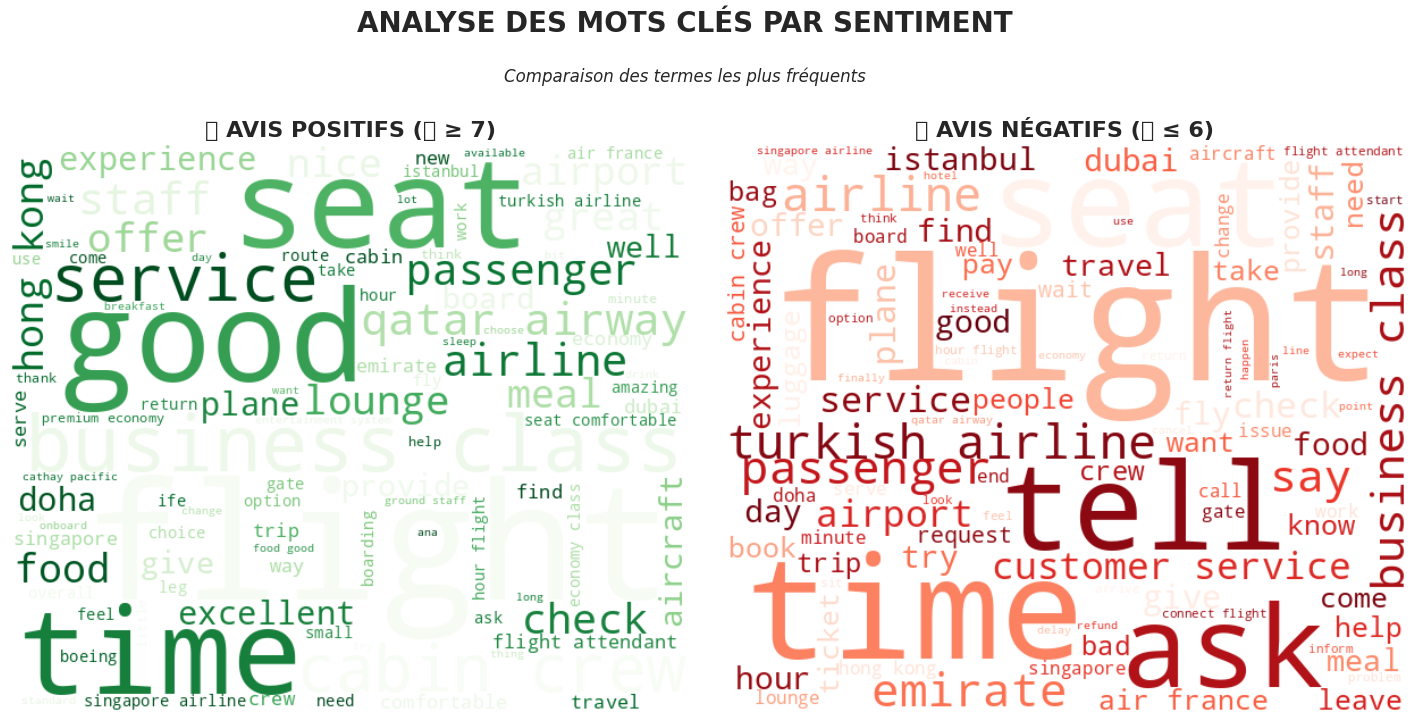

✅ Visualisation terminée
📁 Fichiers sauvegardés:
   • wordcloud_positive.png
   • wordcloud_negative.png
   • wordcloud_comparison.png


In [56]:
# 4. WordCloud - Mots Clés
print("\n" + "="*60)
print("4. WORDCLOUD - Mots Clés ")
print("="*60)

positive_texts = df[df['sentiment_binary'] == 1]['review_clean'].tolist()
negative_texts = df[df['sentiment_binary'] == 0]['review_clean'].tolist()

# Créer une figure avec un espace pour le titre principal
fig = plt.figure(figsize=(18, 9))
gs = fig.add_gridspec(1, 2, hspace=0, wspace=0.05)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

# Wordcloud positif
if positive_texts:
    all_text_pos = " ".join(positive_texts)
    wc_pos = WordCloud(width=600, height=500, background_color='white',
                       colormap='Greens', max_words=100).generate(all_text_pos)
    ax1.imshow(wc_pos, interpolation='bilinear')
    ax1.axis('off')
    ax1.set_title('👍 AVIS POSITIFS (⭐ ≥ 7)', fontsize=16, fontweight='bold')
    wc_pos.to_file(RESULTS_DIR / 'wordcloud_positive.png')

# Wordcloud négatif
if negative_texts:
    all_text_neg = " ".join(negative_texts)
    wc_neg = WordCloud(width=600, height=500, background_color='white',
                       colormap='Reds', max_words=100).generate(all_text_neg)
    ax2.imshow(wc_neg, interpolation='bilinear')
    ax2.axis('off')
    ax2.set_title('👎 AVIS NÉGATIFS (⭐ ≤ 6)', fontsize=16, fontweight='bold')
    wc_neg.to_file(RESULTS_DIR / 'wordcloud_negative.png')


# Titre principal
fig.suptitle('ANALYSE DES MOTS CLÉS PAR SENTIMENT', fontsize=20, fontweight='bold', y=0.96)


# Sous-titre
fig.text(0.5, 0.88, 'Comparaison des termes les plus fréquents', 
         ha='center', fontsize=12, style='italic')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'wordcloud_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Visualisation terminée")
print("📁 Fichiers sauvegardés:")
print("   • wordcloud_positive.png")
print("   • wordcloud_negative.png") 
print("   • wordcloud_comparison.png")

In [57]:
# 5. TF-IDF Vectorisation
print("\n" + "="*60)
print("5. TF-IDF VECTORISATION")
print("="*60)

# Paramètres
MAX_FEATURES = 5000
NGRAM_RANGE = (1, 2)

vectorizer = TfidfVectorizer(
    max_features=MAX_FEATURES,
    ngram_range=NGRAM_RANGE,
    min_df=3,
    max_df=0.8,
    sublinear_tf=True
)

print(f"⏳ Vectorisation avec {MAX_FEATURES} features...")
X = vectorizer.fit_transform(df['review_clean'])
y = df['sentiment_binary'].values

print(f"✅ Matrice TF-IDF: {X.shape}")

# Mots les plus importants par classe
feature_names = vectorizer.get_feature_names_out()
X_array = X.toarray()

positive_avg = X_array[y == 1].mean(axis=0)
negative_avg = X_array[y == 0].mean(axis=0)

top_positive_idx = positive_avg.argsort()[-20:][::-1]
top_negative_idx = negative_avg.argsort()[-20:][::-1]

print(f"\n📊 Top 10 mots dans avis POSITIFS:")
for idx in top_positive_idx[:10]:
    print(f"   • {feature_names[idx]}: {positive_avg[idx]:.4f}")

print(f"\n📊 Top 10 mots dans avis NÉGATIFS:")
for idx in top_negative_idx[:10]:
    print(f"   • {feature_names[idx]}: {negative_avg[idx]:.4f}")


5. TF-IDF VECTORISATION
⏳ Vectorisation avec 5000 features...
✅ Matrice TF-IDF: (8100, 5000)

📊 Top 10 mots dans avis POSITIFS:
   • flight: 0.0451
   • good: 0.0420
   • service: 0.0341
   • seat: 0.0337
   • crew: 0.0328
   • food: 0.0320
   • cabin: 0.0294
   • fly: 0.0270
   • time: 0.0266
   • great: 0.0259

📊 Top 10 mots dans avis NÉGATIFS:
   • flight: 0.0437
   • airline: 0.0335
   • hour: 0.0289
   • seat: 0.0282
   • service: 0.0278
   • time: 0.0255
   • customer: 0.0239
   • tell: 0.0236
   • fly: 0.0234
   • ticket: 0.0226



MOTS LES PLUS DISCRIMINANTS


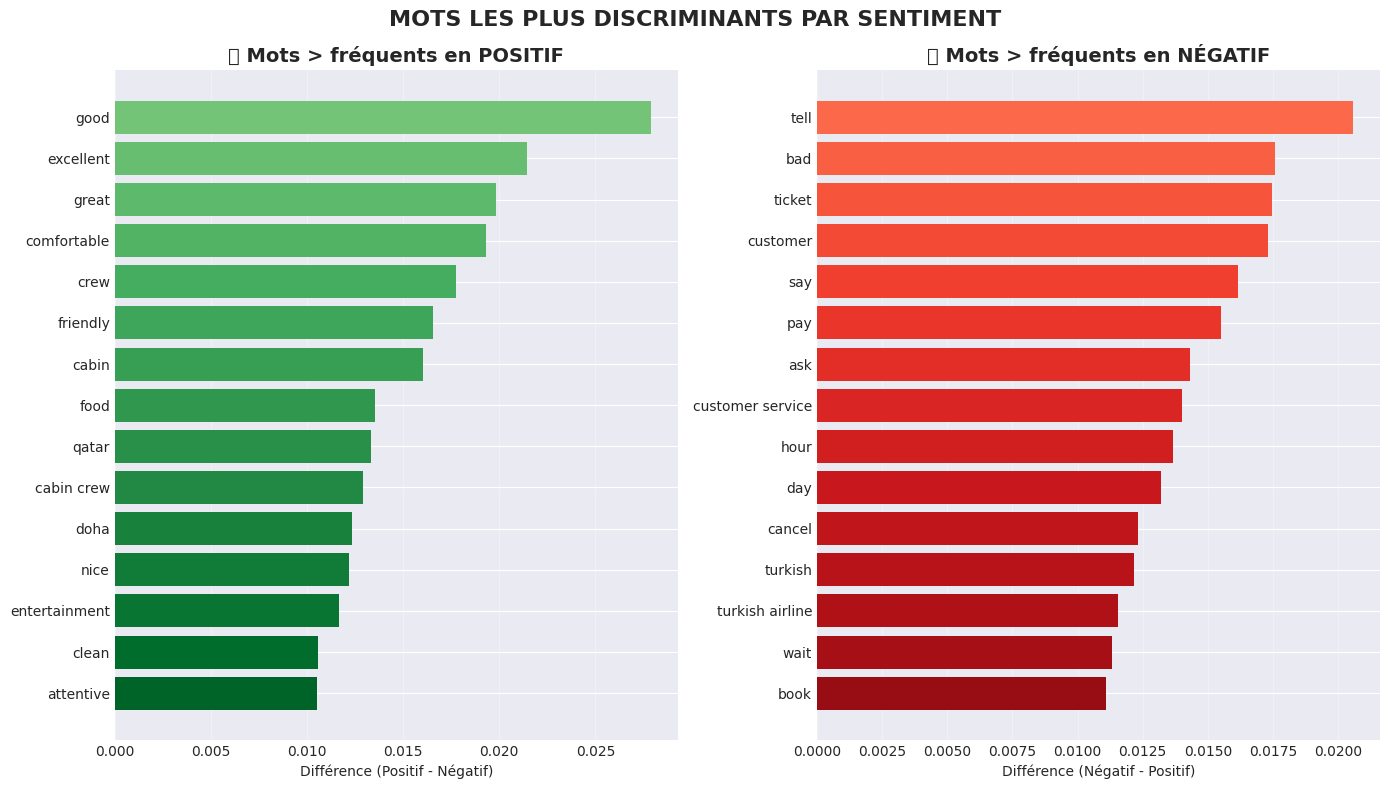

✅ Graphique sauvegardé: discriminative_words.png


In [58]:
# Mots qui DIFFÉRENCIENT le plus Positif vs Négatif
print("\n" + "="*60)
print("MOTS LES PLUS DISCRIMINANTS")
print("="*60)

# Calculer la différence
diff_scores = positive_avg - negative_avg
top_diff_pos_idx = diff_scores.argsort()[-15:][::-1]  # Plus positifs
top_diff_neg_idx = diff_scores.argsort()[:15]        # Plus négatifs

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# Mots plus fréquents dans les avis POSITIFS
words_pos = [feature_names[idx] for idx in top_diff_pos_idx]
scores_pos = [diff_scores[idx] for idx in top_diff_pos_idx]

colors_pos = plt.cm.Greens(np.linspace(0.5, 0.9, len(words_pos)))
bars1 = axes[0].barh(words_pos, scores_pos, color=colors_pos)
axes[0].set_title('🔵 Mots > fréquents en POSITIF', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Différence (Positif - Négatif)')
axes[0].invert_yaxis()
axes[0].grid(True, alpha=0.3, axis='x')

# Mots plus fréquents dans les avis NÉGATIFS
words_neg = [feature_names[idx] for idx in top_diff_neg_idx]
scores_neg = [-diff_scores[idx] for idx in top_diff_neg_idx]  # Valeur absolue

colors_neg = plt.cm.Reds(np.linspace(0.5, 0.9, len(words_neg)))
bars2 = axes[1].barh(words_neg, scores_neg, color=colors_neg)
axes[1].set_title('🔴 Mots > fréquents en NÉGATIF', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Différence (Négatif - Positif)')
axes[1].invert_yaxis()
axes[1].grid(True, alpha=0.3, axis='x')

plt.suptitle('MOTS LES PLUS DISCRIMINANTS PAR SENTIMENT', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'discriminative_words.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Graphique sauvegardé: discriminative_words.png")

In [59]:
# 6. Split Train/Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n✅ Split terminé:")
print(f"   Train: {X_train.shape[0]} samples")
print(f"   Test: {X_test.shape[0]} samples")
print(f"   Train positif ratio: {y_train.mean():.2%}")
print(f"   Test positif ratio: {y_test.mean():.2%}")


✅ Split terminé:
   Train: 6480 samples
   Test: 1620 samples
   Train positif ratio: 48.33%
   Test positif ratio: 48.33%


In [60]:
# 7. Modèles ML pour NLP
print("\n" + "="*60)
print("7. MODÈLES ML POUR NLP")
print("="*60)

models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, 
        C=1.0, 
        random_state=42,
        class_weight='balanced'
    ),
    'Naive Bayes': MultinomialNB(alpha=0.1),
    'Linear SVM': LinearSVC(
        C=1.0, 
        max_iter=2000, 
        random_state=42,
        class_weight='balanced',
        dual='auto'
    )
}

results = []

for name, model in models.items():
    print(f"\n🔹 Entraînement: {name}")
    
    # Entraînement
    model.fit(X_train, y_train)
    
    # Prédictions
    y_pred = model.predict(X_test)
    
    # Métriques
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_proba)
    else:
        y_proba = model.decision_function(X_test)
        auc = roc_auc_score(y_test, y_proba)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'ROC-AUC': auc
    })
    
    print(f"   ✅ Accuracy: {acc:.4f}")
    print(f"   ✅ Precision: {prec:.4f}")
    print(f"   ✅ Recall: {rec:.4f}")
    print(f"   ✅ F1-Score: {f1:.4f}")
    print(f"   ✅ ROC-AUC: {auc:.4f}")
    
    logger.info(f"{name} - Accuracy: {acc:.4f}, F1: {f1:.4f}, AUC: {auc:.4f}")

2026-05-25 01:28:30,081 - INFO - Logistic Regression - Accuracy: 0.8858, F1: 0.8818, AUC: 0.9536
2026-05-25 01:28:30,095 - INFO - Naive Bayes - Accuracy: 0.8580, F1: 0.8598, AUC: 0.9373



7. MODÈLES ML POUR NLP

🔹 Entraînement: Logistic Regression
   ✅ Accuracy: 0.8858
   ✅ Precision: 0.8824
   ✅ Recall: 0.8812
   ✅ F1-Score: 0.8818
   ✅ ROC-AUC: 0.9536

🔹 Entraînement: Naive Bayes
   ✅ Accuracy: 0.8580
   ✅ Precision: 0.8226
   ✅ Recall: 0.9004
   ✅ F1-Score: 0.8598
   ✅ ROC-AUC: 0.9373

🔹 Entraînement: Linear SVM


2026-05-25 01:28:30,198 - INFO - Linear SVM - Accuracy: 0.8778, F1: 0.8702, AUC: 0.9450


   ✅ Accuracy: 0.8778
   ✅ Precision: 0.8937
   ✅ Recall: 0.8480
   ✅ F1-Score: 0.8702
   ✅ ROC-AUC: 0.9450


In [61]:
# 8. Comparaison des Modèles
print("\n" + "="*60)
print("8. COMPARAISON DES MODÈLES")
print("="*60)

results_df = pd.DataFrame(results)
print(results_df.round(4))

# Sauvegarder les résultats
results_df.to_csv(RESULTS_DIR / 'nlp_model_comparison.csv', index=False)
print(f"\n✅ Résultats sauvegardés: nlp_model_comparison.csv")

# Trouver le meilleur modèle
best_model_name = results_df.loc[results_df['F1-Score'].idxmax(), 'Model']
best_f1 = results_df['F1-Score'].max()
best_acc = results_df.loc[results_df['F1-Score'].idxmax(), 'Accuracy']
best_prec = results_df.loc[results_df['F1-Score'].idxmax(), 'Precision']
best_rec = results_df.loc[results_df['F1-Score'].idxmax(), 'Recall']

print(f"\n🏆 MEILLEUR MODÈLE: {best_model_name}")
print(f"   F1-Score: {best_f1:.4f}")
print(f"   Accuracy: {best_acc:.4f}")
print(f"   Precision: {best_prec:.4f}")
print(f"   Recall: {best_rec:.4f}")


8. COMPARAISON DES MODÈLES
                 Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
0  Logistic Regression    0.8858     0.8824  0.8812    0.8818   0.9536
1          Naive Bayes    0.8580     0.8226  0.9004    0.8598   0.9373
2           Linear SVM    0.8778     0.8937  0.8480    0.8702   0.9450

✅ Résultats sauvegardés: nlp_model_comparison.csv

🏆 MEILLEUR MODÈLE: Logistic Regression
   F1-Score: 0.8818
   Accuracy: 0.8858
   Precision: 0.8824
   Recall: 0.8812



9. VISUALISATIONS


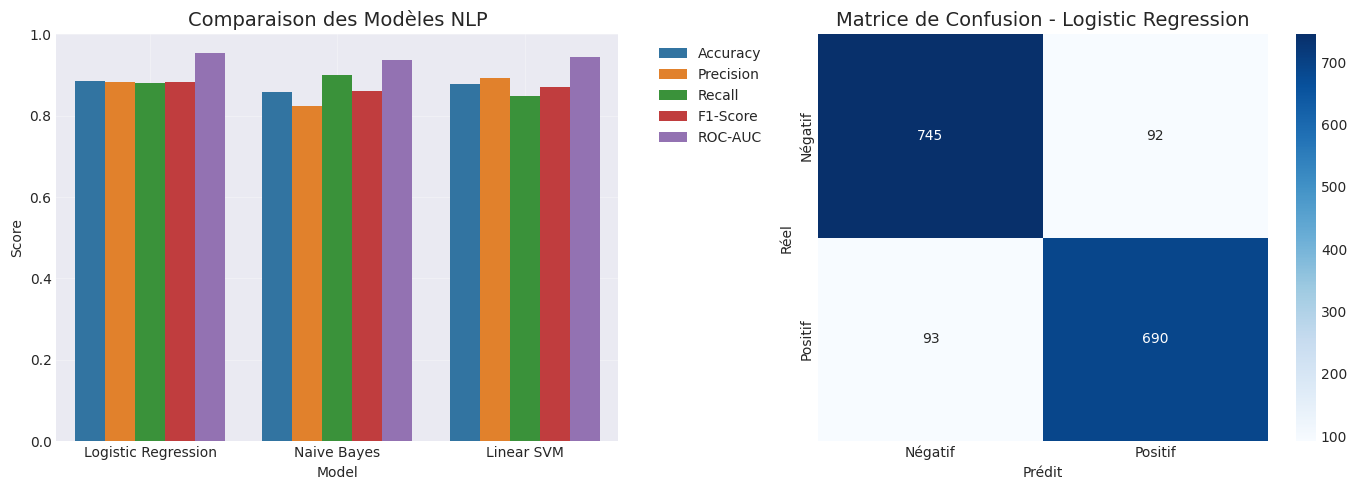

✅ Graphique sauvegardé: nlp_comparison.png


In [62]:
# 9. Visualisation des Résultats
print("\n" + "="*60)
print("9. VISUALISATIONS")
print("="*60)

# Graphique comparatif
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barplot des métriques
results_melted = results_df.melt(id_vars=['Model'], var_name='Metric', value_name='Score')
sns.barplot(data=results_melted, x='Model', y='Score', hue='Metric', ax=axes[0])
axes[0].set_title('Comparaison des Modèles NLP', fontsize=14)
axes[0].set_ylim(0, 1)
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0].grid(True, alpha=0.3)

# Matrices de confusion pour le meilleur modèle
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Négatif', 'Positif'],
            yticklabels=['Négatif', 'Positif'])
axes[1].set_title(f'Matrice de Confusion - {best_model_name}', fontsize=14)
axes[1].set_xlabel('Prédit')
axes[1].set_ylabel('Réel')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'nlp_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Graphique sauvegardé: nlp_comparison.png")

In [63]:
# 10. Feature Importance (mots indicateurs)
print("\n" + "="*60)
print("10. FEATURE IMPORTANCE - MOTS INDICATEURS")
print("="*60)

if best_model_name == 'Linear SVM':
    coefficients = best_model.coef_[0]
elif best_model_name == 'Logistic Regression':
    coefficients = best_model.coef_[0]
else:
    coefficients = best_model.feature_log_prob_[1] - best_model.feature_log_prob_[0]

# Top mots positifs et négatifs
top_n = 20
positive_coeffs_idx = np.argsort(coefficients)[-top_n:][::-1]
negative_coeffs_idx = np.argsort(coefficients)[:top_n]

positive_words = [(feature_names[i], coefficients[i]) for i in positive_coeffs_idx]
negative_words = [(feature_names[i], coefficients[i]) for i in negative_coeffs_idx]

print(f"\n📊 Top 10 mots POSITIFS:")
for word, score in positive_words[:10]:
    print(f"   • {word}: {score:.4f}")

print(f"\n📊 Top 10 mots NÉGATIFS:")
for word, score in negative_words[:10]:
    print(f"   • {word}: {score:.4f}")

# Sauvegarder
importance_df = pd.DataFrame([
    {'word': word, 'score': score, 'sentiment': 'positive'} 
    for word, score in positive_words[:50]
] + [
    {'word': word, 'score': abs(score), 'sentiment': 'negative'} 
    for word, score in negative_words[:50]
])
importance_df.to_csv(RESULTS_DIR / 'word_importance.csv', index=False)


10. FEATURE IMPORTANCE - MOTS INDICATEURS

📊 Top 10 mots POSITIFS:
   • excellent: 5.3554
   • good: 5.1204
   • thank: 4.0343
   • great: 3.6382
   • friendly: 3.5019
   • amazing: 3.3089
   • comfortable: 3.2449
   • helpful: 2.9767
   • professional: 2.8601
   • delicious: 2.7020

📊 Top 10 mots NÉGATIFS:
   • bad: -5.0354
   • poor: -4.0055
   • tell: -3.5142
   • terrible: -3.3068
   • rude: -3.0257
   • say: -2.9628
   • uncomfortable: -2.9356
   • disappointing: -2.8407
   • pay: -2.8312
   • ask: -2.3811


In [64]:
# 11. Sauvegarde du Modèle
print("\n" + "="*60)
print("11. SAUVEGARDE")
print("="*60)

# Sauvegarder le meilleur modèle
model_path = RESULTS_DIR / 'sentiment_nlp_model.joblib'
joblib.dump(best_model, model_path)
print(f"✅ Meilleur modèle sauvegardé: {model_path}")

# Sauvegarder le vectorizer
vectorizer_path = RESULTS_DIR / 'tfidf_vectorizer.joblib'
joblib.dump(vectorizer, vectorizer_path)
print(f"✅ Vectorizer sauvegardé: {vectorizer_path}")

# Sauvegarder la configuration
config = {
    'model_name': best_model_name,
    'max_features': MAX_FEATURES,
    'ngram_range': NGRAM_RANGE,
    'spacy_model': 'en_core_web_sm',
    'training_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    #'train_size': len(X_train),
    #'test_size': len(X_test),
    'train_size': X_train.shape[0],
    'test_size': X_test.shape[0],
    'best_f1': best_f1,
    'best_accuracy': best_acc
}

config_df = pd.DataFrame([config])
config_df.to_csv(RESULTS_DIR / 'model_config.csv', index=False)
print(f"✅ Configuration sauvegardée: model_config.csv")


11. SAUVEGARDE
✅ Meilleur modèle sauvegardé: /home/esprit/airlLines_Project/results_nlp/sentiment_nlp_model.joblib
✅ Vectorizer sauvegardé: /home/esprit/airlLines_Project/results_nlp/tfidf_vectorizer.joblib
✅ Configuration sauvegardée: model_config.csv


In [65]:
# 12. Fonction de Prédiction
def predict_sentiment(text, model, vectorizer, nlp_model):
    """Prédit le sentiment d'un texte"""
    processed = preprocess_text_spacy(text)
    
    if processed == "":
        return "Neutre", 0.5
    
    X_pred = vectorizer.transform([processed])
    
    if hasattr(model, 'predict_proba'):
        proba = model.predict_proba(X_pred)[0]
        sentiment = "Positif" if proba[1] > 0.5 else "Négatif"
        confidence = max(proba)
    else:
        score = model.decision_function(X_pred)[0]
        sentiment = "Positif" if score > 0 else "Négatif"
        confidence = 1 / (1 + np.exp(-abs(score)))
    
    return sentiment, confidence

# Test
test_texts = [
    "The flight was amazing, great service and comfortable seats!",
    "Terrible experience, flight delayed for 5 hours and rude staff",
    "Average flight, nothing special but got me there on time"
]

print("\n📝 Test de prédiction:")
for text in test_texts:
    sentiment, confidence = predict_sentiment(text, best_model, vectorizer, nlp)
    print(f"\n   Texte: {text[:60]}...")
    print(f"   Sentiment: {sentiment} (confiance: {confidence:.2%})")


📝 Test de prédiction:

   Texte: The flight was amazing, great service and comfortable seats!...
   Sentiment: Positif (confiance: 96.61%)

   Texte: Terrible experience, flight delayed for 5 hours and rude sta...
   Sentiment: Négatif (confiance: 96.41%)

   Texte: Average flight, nothing special but got me there on time...
   Sentiment: Négatif (confiance: 76.23%)


In [66]:
# 13. Résumé Final
print("\n" + "="*60)
print("13. RÉSUMÉ FINAL")
print("="*60)

best_nlp_metrics = {
    'Accuracy': best_acc,
    'Precision': best_prec,
    'Recall': best_rec,
    'F1': best_f1
}

print(f"""
╔════════════════════════════════════════════════════════════╗
║            ANALYSE NLP TERMINÉE                            ║
╚════════════════════════════════════════════════════════════╝

NLP Framework: spaCy

Modèles NLP testés:
   • Logistic Regression
   • Naive Bayes  
   • Linear SVM

🏆 MEILLEUR MODÈLE: {best_model_name}

Meilleures métriques:
   • Accuracy:  {best_nlp_metrics['Accuracy']:.4f}
   • Precision: {best_nlp_metrics['Precision']:.4f}
   • Recall:    {best_nlp_metrics['Recall']:.4f}
   • F1-Score:  {best_nlp_metrics['F1']:.4f}

Fichiers sauvegardés dans results_nlp/:
   • nlp_model_comparison.csv
   • wordcloud_positive.png
   • wordcloud_negative.png
   • nlp_comparison.png
   • word_importance.csv
   • sentiment_nlp_model.joblib
   • tfidf_vectorizer.joblib
   • model_config.csv
   • nlp_training.log

Prochaine étape: 05_ensemble_ml_nlp.ipynb
""")

logger.info(f"=== NLP SESSION COMPLETED ===")
logger.info(f"Best model: {best_model_name}, F1: {best_f1:.4f}")

2026-05-25 01:28:30,982 - INFO - === NLP SESSION COMPLETED ===
2026-05-25 01:28:30,984 - INFO - Best model: Logistic Regression, F1: 0.8818



13. RÉSUMÉ FINAL

╔════════════════════════════════════════════════════════════╗
║            ANALYSE NLP TERMINÉE                            ║
╚════════════════════════════════════════════════════════════╝

NLP Framework: spaCy

Modèles NLP testés:
   • Logistic Regression
   • Naive Bayes  
   • Linear SVM

🏆 MEILLEUR MODÈLE: Logistic Regression

Meilleures métriques:
   • Accuracy:  0.8858
   • Precision: 0.8824
   • Recall:    0.8812
   • F1-Score:  0.8818

Fichiers sauvegardés dans results_nlp/:
   • nlp_model_comparison.csv
   • wordcloud_positive.png
   • wordcloud_negative.png
   • nlp_comparison.png
   • word_importance.csv
   • sentiment_nlp_model.joblib
   • tfidf_vectorizer.joblib
   • model_config.csv
   • nlp_training.log

Prochaine étape: 05_ensemble_ml_nlp.ipynb

